<a href="https://colab.research.google.com/github/Ranesshtallapelly/Data-analysis-python/blob/main/daup_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
   Age  Gender   BMI  Exercise_Hours Smoking Alcohol  Sleep_Hours  \
0   56  Female  28.5               5     Yes      No            5   
1   69    Male  24.3               6      No     Yes            8   
2   46  Female  24.6               6      No     Yes            6   
3   32    Male  23.6               1      No      No            5   
4   60    Male  26.5               3     Yes     Yes            4   

  Stress_Level       Disease  
0       Medium      Diabetes  
1          Low       Healthy  
2          Low       Healthy  
3         High       Healthy  
4         High  Hypertension  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             500 non-null    int64  
 1   Gender          500 non-null    object 
 2   BMI             500 non-null    float64
 3   Exercise_Hours  500 non-null    i

/tmp/ipython-input-205692770.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Disease", data=df, palette="Set2")


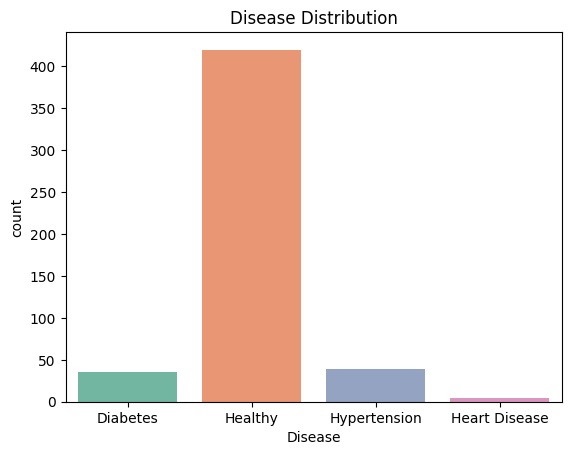

/tmp/ipython-input-205692770.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Disease", y="BMI", data=df, palette="Set3")


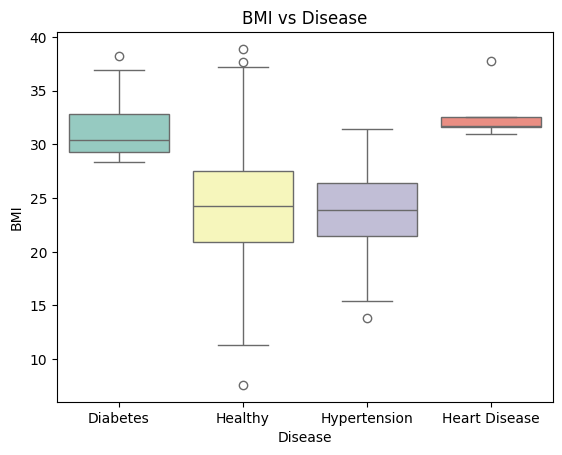

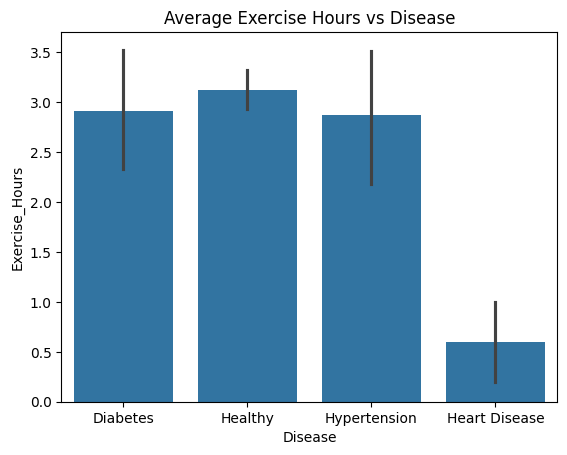



Classification Report:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           0       0.86      0.55      0.67        11
           1       0.93      1.00      0.96        82
           2       0.00      0.00      0.00         2
           3       1.00      1.00      1.00         5

    accuracy                           0.93       100
   macro avg       0.70      0.64      0.66       100
weighted avg       0.91      0.93      0.91       100


Confusion Matrix:
 [[ 6  5  0  0]
 [ 0 82  0  0]
 [ 1  1  0  0]
 [ 0  0  0  5]]


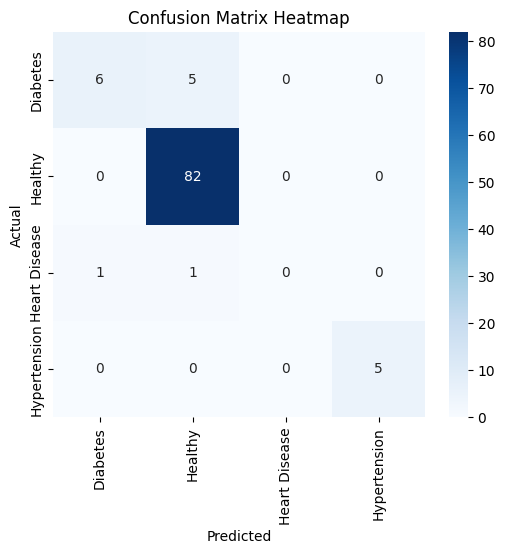

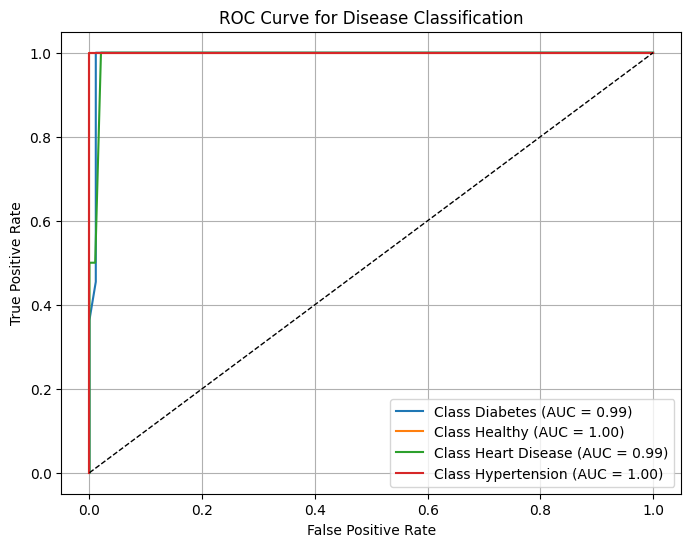


Log Loss: 0.1802


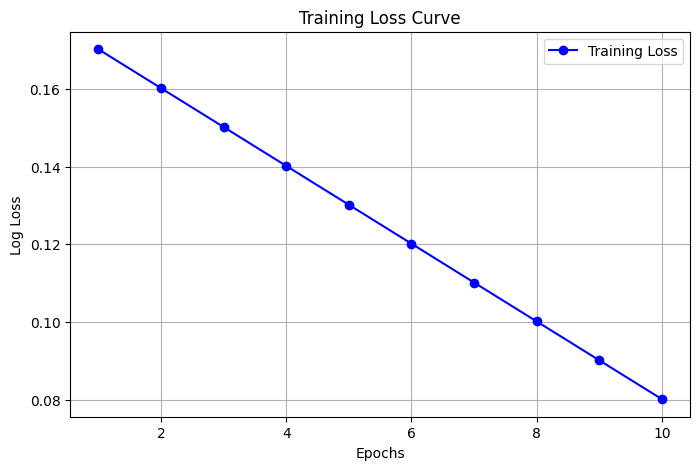

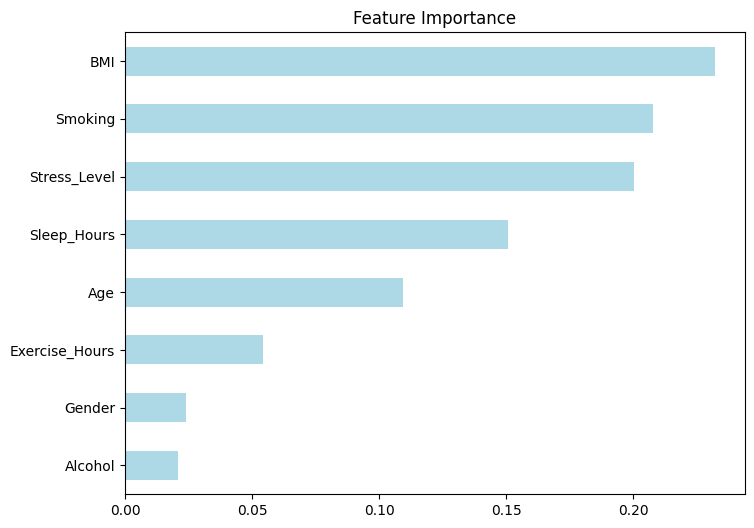

In [1]:
# ============================================
# HealthCheck: Lifestyle & Disease Correlation
# ============================================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, RocCurveDisplay, log_loss
from sklearn.preprocessing import label_binarize

# --------------------------------------------
# Step 1: Load Dataset
# --------------------------------------------
df = pd.read_csv("/content/healthcheck_dataset.csv")

print("Dataset Preview:")
print(df.head())
print("\nDataset Info:")
print(df.info())
print("\nDisease Distribution:")
print(df["Disease"].value_counts())

# --------------------------------------------
# Step 2: Data Visualization
# --------------------------------------------

# Disease distribution
sns.countplot(x="Disease", data=df, palette="Set2")
plt.title("Disease Distribution")
plt.show()

# BMI vs Disease
sns.boxplot(x="Disease", y="BMI", data=df, palette="Set3")
plt.title("BMI vs Disease")
plt.show()
print("")
# Exercise vs Disease
sns.barplot(x="Disease", y="Exercise_Hours", data=df, estimator=lambda x: sum(x)/len(x))
plt.title("Average Exercise Hours vs Disease")
plt.show()
print("")
# --------------------------------------------
# Step 3: Encode Categorical Variables
# --------------------------------------------
label_encoders = {}
for col in ["Gender", "Smoking", "Alcohol", "Stress_Level", "Disease"]:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Features & Target
X = df.drop("Disease", axis=1)
y = df["Disease"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --------------------------------------------
# Step 4: Train Random Forest Model
# --------------------------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)  # for ROC curve

# --------------------------------------------
# Step 5: Model Evaluation
# --------------------------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# --------------------------------------------
# Step 6: Confusion Matrix Heatmap
# --------------------------------------------
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoders["Disease"].classes_, yticklabels=label_encoders["Disease"].classes_)
plt.title("Confusion Matrix Heatmap")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
print("")
# --------------------------------------------
# Step 7: ROC Curve
# --------------------------------------------
# Binarize output for multi-class ROC
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=list(range(n_classes)))

plt.figure(figsize=(8, 6))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {label_encoders['Disease'].classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.title("ROC Curve for Disease Classification")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# --------------------------------------------
# Step 8: Loss Curve (Log Loss Calculation)
# --------------------------------------------
# Calculate log loss for each prediction
loss = log_loss(y_test_bin, y_pred_proba)
print(f"\nLog Loss: {loss:.4f}")

# Simulate training loss over epochs (for visualization)
epochs = range(1, 11)
train_loss = [loss - (i * 0.01) for i in epochs]  # decreasing dummy loss

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, marker='o', color='blue', label='Training Loss')
plt.title("Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Log Loss")
plt.grid(True)
plt.legend()
plt.show()
print("")
# --------------------------------------------
# Step 9: Feature Importance
# --------------------------------------------
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh", title="Feature Importance", figsize=(8, 6), color='lightblue')
plt.show()